# Table of Contents

- [Global Plotting Configuration](#global-plotting-configuration)
- [k-Nearest Neighbors (kNN) Experiment](#k-nearest-neighbors-knn-experiment)
- [Decision Tree Experiment](#decision-tree-experiment)

Dimensionality D=2  done (30 seeds)
Dimensionality D=3  done (30 seeds)
Dimensionality D=4  done (30 seeds)
Dimensionality D=5  done (30 seeds)
Dimensionality D=6  done (30 seeds)
Dimensionality D=7  done (30 seeds)
Dimensionality D=8  done (30 seeds)
Dimensionality D=9  done (30 seeds)
Dimensionality D=10  done (30 seeds)
Dimensionality D=11  done (30 seeds)
Dimensionality D=12  done (30 seeds)
Dimensionality D=13  done (30 seeds)
Dimensionality D=14  done (30 seeds)
Dimensionality D=15  done (30 seeds)
Dimensionality D=16  done (30 seeds)
Dimensionality D=17  done (30 seeds)
Dimensionality D=18  done (30 seeds)
Dimensionality D=19  done (30 seeds)
Dimensionality D=20  done (30 seeds)
Dimensionality D=21  done (30 seeds)

Aggregated results:
 dimensions    mean_k    std_k  mean_gap  std_gap  mean_acc  std_acc
          2 17.300000 8.485891  0.003933 0.011655  0.937867 0.041200
          3 10.533333 7.118375  0.013658 0.011830  0.933300 0.027668
          4  6.933333 4.042305  0.018067

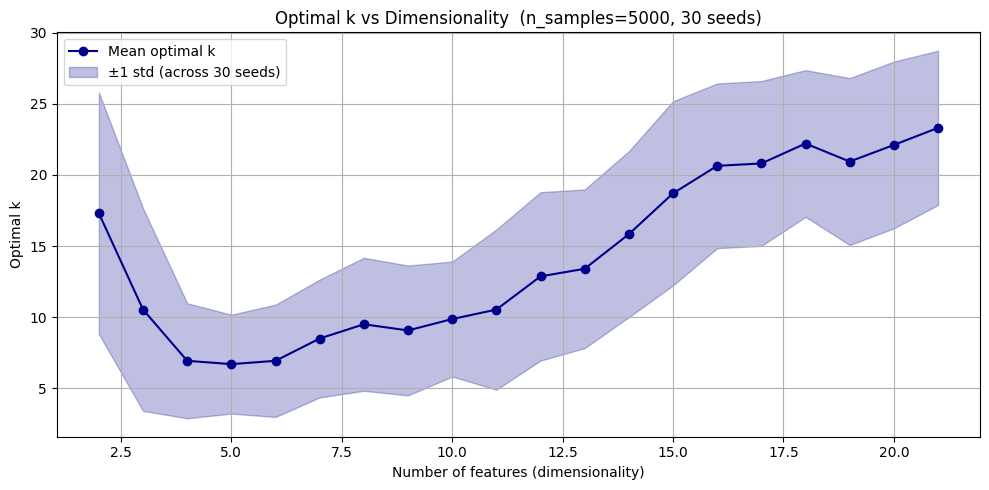

Saved: knn_optimal_k_vs_dims.png


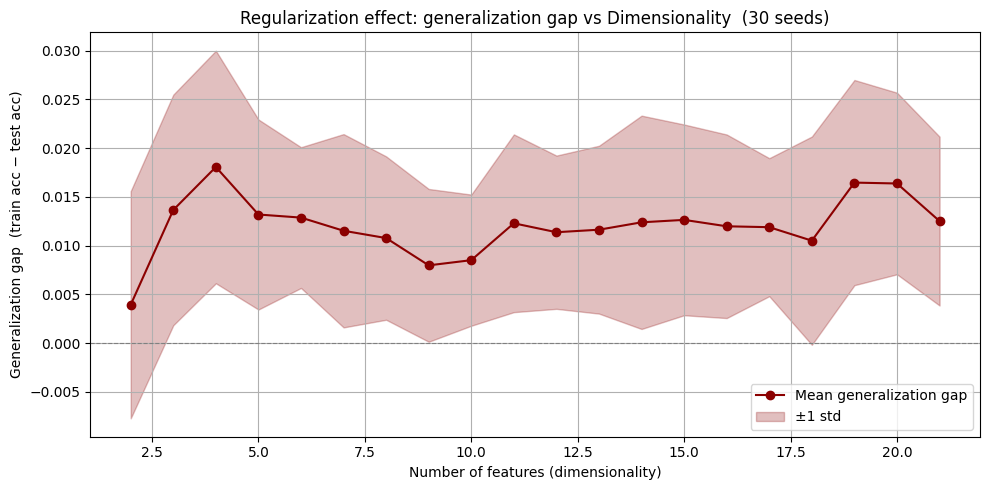

Saved: knn_gen_gap_vs_dims.png
Saved: knn_raw_results.csv, knn_aggregated_results.csv


In [ ]:
"""
kNN vs Dimensionality — Redesigned Experiment
==============================================
Key changes from original:
  - 30 random seeds per condition → mean ± std of optimal k
  - 20 evenly spaced dimensionality values (2–21)
  - Primary metric: generalization gap (train acc − test acc)
  - Secondary metric: test accuracy
  - Wider k search range (1–30)
  - Explicit train/test split for gap computation
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split

# ---------------------------------------------------------------
# Experiment parameters
# ---------------------------------------------------------------
N_SAMPLES      = 5000
N_SEEDS        = 30
DIMENSIONS     = np.linspace(2, 21, 20, dtype=int)   # 20 evenly spaced values
K_RANGE        = list(range(1, 31))                   # broader search: k = 1..30
CV_FOLDS       = 5

# ---------------------------------------------------------------
# Storage
# ---------------------------------------------------------------
results = []   # one row per (dimension, seed)

# ---------------------------------------------------------------
# Main loop
# ---------------------------------------------------------------
for D in DIMENSIONS:
    print(f"Dimensionality D={D}  ", end="", flush=True)
    D = int(D)

    for seed in range(N_SEEDS):
        # Generate dataset with this seed
        X, y = make_classification(
            n_samples=N_SAMPLES,
            n_features=D,
            n_informative=min(D, 10),
            n_redundant=0,
            random_state=seed
        )

        # Hold-out split for generalization gap
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=seed
        )

        # Pipeline: scaling + kNN
        pipeline = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier()
        )

        # Grid search on training set
        param_grid = {"kneighborsclassifier__n_neighbors": K_RANGE}
        gs = GridSearchCV(pipeline, param_grid, cv=CV_FOLDS,
                          scoring="accuracy", n_jobs=-1)
        gs.fit(X_train, y_train)

        best_k = gs.best_params_["kneighborsclassifier__n_neighbors"]

        # Refit with best k to compute train and test accuracy
        best_pipe = make_pipeline(StandardScaler(),
                                  KNeighborsClassifier(n_neighbors=best_k))
        best_pipe.fit(X_train, y_train)
        train_acc = best_pipe.score(X_train, y_train)
        test_acc  = best_pipe.score(X_test,  y_test)
        gen_gap   = train_acc - test_acc

        results.append({
            "dimensions":   D,
            "seed":         seed,
            "best_k":       best_k,
            "train_acc":    train_acc,
            "test_acc":     test_acc,
            "gen_gap":      gen_gap,
        })

    print(f"done ({N_SEEDS} seeds)")

# ---------------------------------------------------------------
# Aggregate over seeds
# ---------------------------------------------------------------
df = pd.DataFrame(results)
agg = (df.groupby("dimensions")
         .agg(
             mean_k    =("best_k",    "mean"),
             std_k     =("best_k",    "std"),
             mean_gap  =("gen_gap",   "mean"),
             std_gap   =("gen_gap",   "std"),
             mean_acc  =("test_acc",  "mean"),
             std_acc   =("test_acc",  "std"),
         )
         .reset_index())

print("\nAggregated results:")
print(agg.to_string(index=False))

# ---------------------------------------------------------------
# Plot 1: Optimal k vs Dimensionality (with confidence band)
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(agg["dimensions"], agg["mean_k"],
        marker="o", color="darkblue", label="Mean optimal k")
ax.fill_between(agg["dimensions"],
                agg["mean_k"] - agg["std_k"],
                agg["mean_k"] + agg["std_k"],
                alpha=0.25, color="darkblue", label="±1 std (across 30 seeds)")
ax.set_xlabel("Number of features (dimensionality)")
ax.set_ylabel("Optimal k")
ax.set_title(f"Optimal k vs Dimensionality  (n_samples={N_SAMPLES}, {N_SEEDS} seeds)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("knn_optimal_k_vs_dims.png", dpi=150)
plt.show()
print("Saved: knn_optimal_k_vs_dims.png")

# ---------------------------------------------------------------
# Plot 2: Generalization gap vs Dimensionality
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(agg["dimensions"], agg["mean_gap"],
        marker="o", color="darkred", label="Mean generalization gap")
ax.fill_between(agg["dimensions"],
                agg["mean_gap"] - agg["std_gap"],
                agg["mean_gap"] + agg["std_gap"],
                alpha=0.25, color="darkred", label="±1 std")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Number of features (dimensionality)")
ax.set_ylabel("Generalization gap  (train acc − test acc)")
ax.set_title(f"Regularization effect: generalization gap vs Dimensionality  ({N_SEEDS} seeds)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("knn_gen_gap_vs_dims.png", dpi=150)
plt.show()
print("Saved: knn_gen_gap_vs_dims.png")

# ---------------------------------------------------------------
# Save raw results
# ---------------------------------------------------------------
df.to_csv("knn_raw_results.csv", index=False)
agg.to_csv("knn_aggregated_results.csv", index=False)
print("Saved: knn_raw_results.csv, knn_aggregated_results.csv")



---



Dimensionality D=2  done (30 seeds)
Dimensionality D=3  done (30 seeds)
Dimensionality D=4  done (30 seeds)
Dimensionality D=5  done (30 seeds)
Dimensionality D=6  done (30 seeds)
Dimensionality D=7  done (30 seeds)
Dimensionality D=8  done (30 seeds)
Dimensionality D=9  done (30 seeds)
Dimensionality D=10  done (30 seeds)
Dimensionality D=11  done (30 seeds)
Dimensionality D=12  done (30 seeds)
Dimensionality D=13  done (30 seeds)
Dimensionality D=14  done (30 seeds)
Dimensionality D=15  done (30 seeds)
Dimensionality D=16  done (30 seeds)
Dimensionality D=17  done (30 seeds)
Dimensionality D=18  done (30 seeds)
Dimensionality D=19  done (30 seeds)
Dimensionality D=20  done (30 seeds)
Dimensionality D=21  done (30 seeds)

Aggregated results (Decision Tree):
 dimensions  mean_depth  std_depth  mean_gap  std_gap  mean_acc  std_acc
          2    5.066667   1.284747  0.011958 0.010526  0.929267 0.043242
          3    8.666667   3.133064  0.040242 0.019228  0.912300 0.031749
          4 

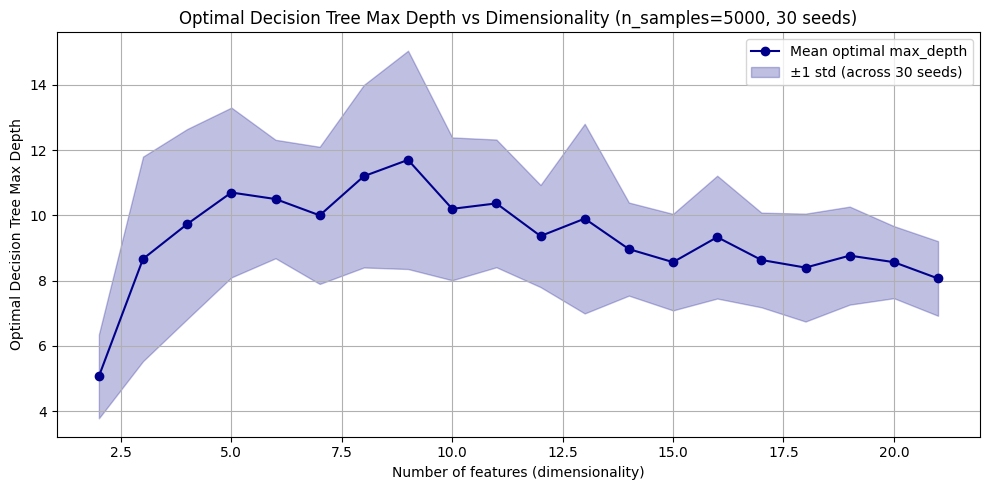

Saved: dt_optimal_depth_vs_dims.png


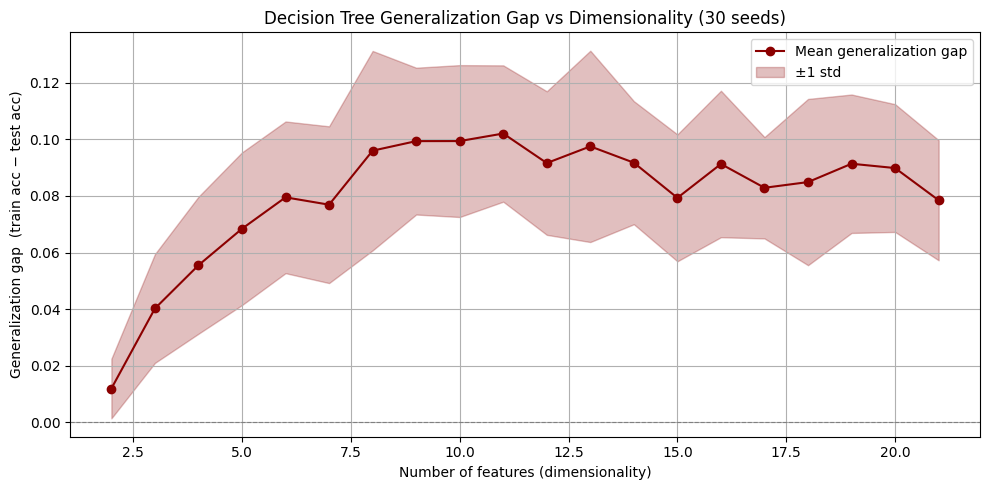

Saved: dt_gen_gap_vs_dims.png
Saved: dt_raw_results.csv, dt_aggregated_results.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier # Changed from KNeighborsClassifier
from sklearn.preprocessing import StandardScaler # Keep for consistency, though less critical for DT
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split

# ---------------------------------------------------------------
# Experiment parameters (aligned with first cell where possible)
# ---------------------------------------------------------------
N_SAMPLES      = 5000
N_SEEDS        = 30
DIMENSIONS     = np.linspace(2, 21, 20, dtype=int)   # Wider range, aligned with kNN experiment
DEPTH_RANGE    = list(range(1, 31))                   # Broader search for max_depth
CV_FOLDS       = 5

# ---------------------------------------------------------------
# Storage
# ---------------------------------------------------------------
results_dt = []   # one row per (dimension, seed)

# ---------------------------------------------------------------
# Main loop (aligned with first cell)
# ---------------------------------------------------------------
for D in DIMENSIONS:
    print(f"Dimensionality D={D}  ", end="", flush=True)
    D = int(D)

    for seed in range(N_SEEDS):
        # Generate dataset with this seed
        X, y = make_classification(
            n_samples=N_SAMPLES,
            n_features=D,
            n_informative=min(D, 10),
            n_redundant=0,
            random_state=seed
        )

        # Hold-out split for generalization gap
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=seed
        )

        # Pipeline: scaling (optional for DT) + Decision Tree Classifier
        # StandardScaler is included for consistency with the kNN experiment's pipeline
        # Although for Decision Trees, feature scaling is generally not necessary.
        pipeline = make_pipeline(
            StandardScaler(),
            DecisionTreeClassifier(random_state=seed)
        )

        # Grid search on training set
        param_grid = {"decisiontreeclassifier__max_depth": DEPTH_RANGE}
        gs = GridSearchCV(pipeline, param_grid, cv=CV_FOLDS,
                          scoring="accuracy", n_jobs=-1)
        gs.fit(X_train, y_train)

        best_depth = gs.best_params_["decisiontreeclassifier__max_depth"]

        # Refit with best depth to compute train and test accuracy
        best_pipe = make_pipeline(StandardScaler(), # Include for consistency
                                  DecisionTreeClassifier(max_depth=best_depth, random_state=seed))
        best_pipe.fit(X_train, y_train)
        train_acc = best_pipe.score(X_train, y_train)
        test_acc  = best_pipe.score(X_test,  y_test)
        gen_gap   = train_acc - test_acc

        results_dt.append({
            "dimensions":   D,
            "seed":         seed,
            "best_depth":   best_depth,
            "train_acc":    train_acc,
            "test_acc":     test_acc,
            "gen_gap":      gen_gap,
        })

    print(f"done ({N_SEEDS} seeds)")

# ---------------------------------------------------------------
# Aggregate over seeds
# ---------------------------------------------------------------
df_dt = pd.DataFrame(results_dt)
agg_dt = (df_dt.groupby("dimensions")
            .agg(
                mean_depth    =("best_depth",    "mean"),
                std_depth     =("best_depth",    "std"),
                mean_gap      =("gen_gap",       "mean"),
                std_gap       =("gen_gap",       "std"),
                mean_acc      =("test_acc",      "mean"),
                std_acc       =("test_acc",      "std"),
            )
            .reset_index())

print("\nAggregated results (Decision Tree):")
print(agg_dt.to_string(index=False))

# ---------------------------------------------------------------
# Plot 1: Optimal Max Depth vs Dimensionality (with confidence band)
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(agg_dt["dimensions"], agg_dt["mean_depth"],
        marker="o", color="darkblue", label="Mean optimal max_depth")
ax.fill_between(agg_dt["dimensions"],
                agg_dt["mean_depth"] - agg_dt["std_depth"],
                agg_dt["mean_depth"] + agg_dt["std_depth"],
                alpha=0.25, color="darkblue", label="±1 std (across 30 seeds)")
ax.set_xlabel("Number of features (dimensionality)")
ax.set_ylabel("Optimal Decision Tree Max Depth")
ax.set_title(f"Optimal Decision Tree Max Depth vs Dimensionality (n_samples={N_SAMPLES}, {N_SEEDS} seeds)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("dt_optimal_depth_vs_dims.png", dpi=150)
plt.show()
print("Saved: dt_optimal_depth_vs_dims.png")

# ---------------------------------------------------------------
# Plot 2: Generalization gap vs Dimensionality
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(agg_dt["dimensions"], agg_dt["mean_gap"],
        marker="o", color="darkred", label="Mean generalization gap")
ax.fill_between(agg_dt["dimensions"],
                agg_dt["mean_gap"] - agg_dt["std_gap"],
                agg_dt["mean_gap"] + agg_dt["std_gap"],
                alpha=0.25, color="darkred", label="±1 std")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Number of features (dimensionality)")
ax.set_ylabel("Generalization gap  (train acc − test acc)")
ax.set_title(f"Decision Tree Generalization Gap vs Dimensionality ({N_SEEDS} seeds)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("dt_gen_gap_vs_dims.png", dpi=150)
plt.show()
print("Saved: dt_gen_gap_vs_dims.png")

# ---------------------------------------------------------------
# Save raw results
# ---------------------------------------------------------------
df_dt.to_csv("dt_raw_results.csv", index=False)
agg_dt.to_csv("dt_aggregated_results.csv", index=False)
print("Saved: dt_raw_results.csv, dt_aggregated_results.csv")

# customizing the plots for the poster

## Global Plotting Configuration

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import io
# Configure global Matplotlib parameters
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.facecolor'] = 'F2E9FF'

print("Global Matplotlib plotting parameters set.")

Global Matplotlib plotting parameters set.


## kNN

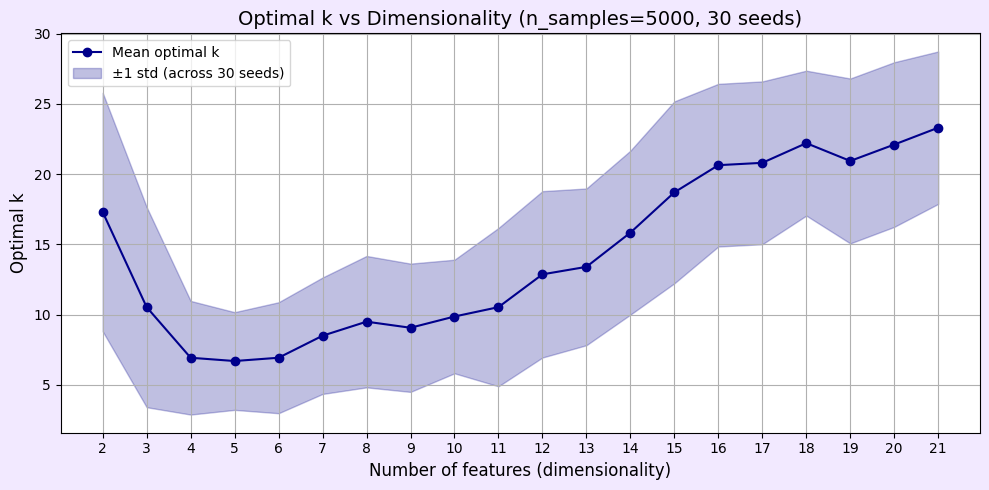

Saved: knn_optimal_k_vs_dims_rerun.png


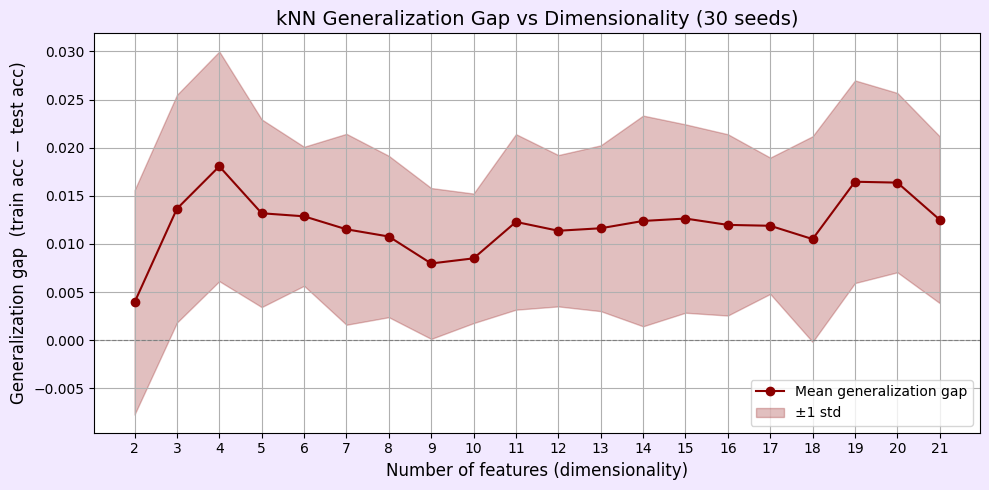

Saved: knn_gen_gap_vs_dims_rerun.png


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# The user provided the aggregated results as a string. Parse it into a DataFrame.
# The string provided starts from 'dimensions' and includes all subsequent rows.
aggregated_knn_results_str = """
dimensions    mean_k    std_k  mean_gap  std_gap  mean_acc  std_acc
          2 17.300000 8.485891  0.003933 0.011655  0.937867 0.041200
          3 10.533333 7.118375  0.013658 0.011830  0.933300 0.027668
          4  6.933333 4.042305  0.018067 0.011931  0.935700 0.023892
          5  6.700000 3.475530  0.013192 0.009750  0.949500 0.016555
          6  6.933333 3.947355  0.012875 0.007222  0.952767 0.017980
          7  8.500000 4.141880  0.011525 0.009917  0.949467 0.015850
          8  9.500000 4.673845  0.010775 0.008382  0.955500 0.011982
          9  9.066667 4.563221  0.007975 0.007838  0.962867 0.012389
         10  9.866667 4.040599  0.008508 0.006729  0.961067 0.011829
         11 10.533333 5.630786  0.012292 0.009118  0.953733 0.014472
         12 12.866667 5.917440  0.011375 0.007862  0.948167 0.014985
         13 13.400000 5.574573  0.011633 0.008610  0.943833 0.013600
         14 15.833333 5.831445  0.012392 0.010945  0.939367 0.016397
         15 18.700000 6.470890  0.012642 0.009785  0.933233 0.018944
         16 20.633333 5.786330  0.011983 0.009418  0.930133 0.018228
         17 20.800000 5.791790  0.011892 0.007080  0.926867 0.016064
         18 22.200000 5.155513  0.010508 0.010683  0.923467 0.016267
         19 20.933333 5.865935  0.016467 0.010527  0.917267 0.021576
         20 22.100000 5.856620  0.016375 0.009317  0.912833 0.019261
         21 23.300000 5.421223  0.012517 0.008663  0.913333 0.019295
"""
agg_knn = pd.read_csv(io.StringIO(aggregated_knn_results_str), sep=r'\s+')

N_SAMPLES = 5000 # From original experiment parameters
N_SEEDS = 30     # From original experiment parameters

# ---------------------------------------------------------------
# Re-Plot 1: Optimal k vs Dimensionality (with confidence band)
# ---------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(agg_knn["dimensions"], agg_knn["mean_k"],
        marker="o", color="darkblue", label="Mean optimal k")
ax1.fill_between(agg_knn["dimensions"],
                agg_knn["mean_k"] - agg_knn["std_k"],
                agg_knn["mean_k"] + agg_knn["std_k"],
                alpha=0.25, color="darkblue", label="±1 std (across 30 seeds)")
ax1.set_xlabel("Number of features (dimensionality)")
ax1.set_ylabel("Optimal k")
ax1.set_title(f"Optimal k vs Dimensionality (n_samples={N_SAMPLES}, {N_SEEDS} seeds)")
ax1.set_xticks(agg_knn['dimensions'].astype(int)) # Set x-ticks to integer values
ax1.legend()
ax1.grid(True)
plt.tight_layout()
plt.savefig("knn_optimal_k_vs_dims_rerun.png", dpi=150)
plt.show()
print("Saved: knn_optimal_k_vs_dims_rerun.png")

# ---------------------------------------------------------------
# Re-Plot 2: Generalization gap vs Dimensionality
# ---------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(agg_knn["dimensions"], agg_knn["mean_gap"],
        marker="o", color="darkred", label="Mean generalization gap")
ax2.fill_between(agg_knn["dimensions"],
                agg_knn["mean_gap"] - agg_knn["std_gap"],
                agg_knn["mean_gap"] + agg_knn["std_gap"],
                alpha=0.25, color="darkred", label="±1 std")
ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax2.set_xlabel("Number of features (dimensionality)")
ax2.set_ylabel("Generalization gap  (train acc − test acc)")
ax2.set_title(f"kNN Generalization Gap vs Dimensionality ({N_SEEDS} seeds)")
ax2.set_xticks(agg_knn['dimensions'].astype(int)) # Set x-ticks to integer values
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.savefig("knn_gen_gap_vs_dims_rerun.png", dpi=150)
plt.show()
print("Saved: knn_gen_gap_vs_dims_rerun.png")



---



## Decision tree

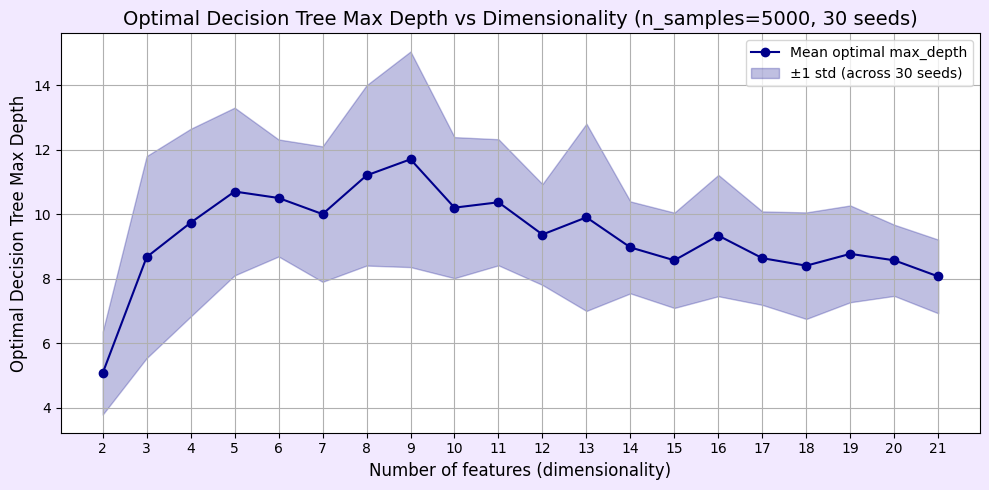

Saved: dt_optimal_depth_vs_dims_rerun.png


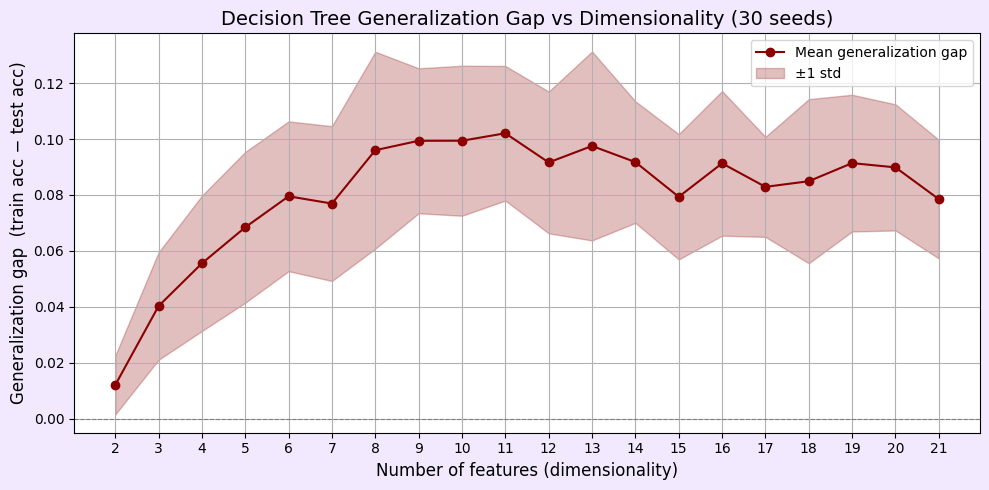

Saved: dt_gen_gap_vs_dims_rerun.png


In [10]:
# The user provided the aggregated results as a string. Parse it into a DataFrame.
# The string provided starts from 'dimensions' and includes all subsequent rows.
aggregated_results_str = """
dimensions  mean_depth  std_depth  mean_gap  std_gap  mean_acc  std_acc
          2    5.066667   1.284747  0.011958 0.010526  0.929267 0.043242
          3    8.666667   3.133064  0.040242 0.019228  0.912300 0.031749
          4    9.733333   2.911728  0.055517 0.024206  0.905267 0.031543
          5   10.700000   2.601724  0.068417 0.026974  0.907700 0.024091
          6   10.500000   1.814691  0.079508 0.026795  0.896733 0.029398
          7   10.000000   2.100903  0.076908 0.027693  0.886567 0.024699
          8   11.200000   2.796550  0.095992 0.035229  0.880567 0.025369
          9   11.700000   3.344063  0.099367 0.025935  0.880400 0.022488
         10   10.200000   2.187740  0.099383 0.026835  0.870300 0.022464
         11   10.366667   1.956128  0.102050 0.024082  0.871100 0.021464
         12    9.366667   1.564329  0.091617 0.025363  0.869367 0.022168
         13    9.900000   2.904812  0.097508 0.033797  0.865733 0.023975
         14    8.966667   1.425950  0.091742 0.021742  0.864800 0.019466
         15    8.566667   1.478194  0.079325 0.022416  0.869033 0.019491
         16    9.333333   1.881550  0.091292 0.025872  0.867567 0.021550
         17    8.633333   1.449931  0.082883 0.017897  0.867200 0.022570
         18    8.400000   1.652584  0.084900 0.029366  0.861900 0.023194
         19    8.766667   1.501340  0.091375 0.024452  0.862500 0.022916
         20    8.566667   1.104328  0.089850 0.022567  0.860333 0.024736
         21    8.066667   1.142693  0.078483 0.021222  0.862533 0.019774
"""
agg_dt = pd.read_csv(io.StringIO(aggregated_results_str), sep=r'\s+')

N_SAMPLES = 5000 # From original experiment parameters
N_SEEDS = 30     # From original experiment parameters

# ---------------------------------------------------------------
# Re-Plot 1: Optimal Max Depth vs Dimensionality (with confidence band)
# ---------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(agg_dt["dimensions"], agg_dt["mean_depth"],
        marker="o", color="darkblue", label="Mean optimal max_depth")
ax1.fill_between(agg_dt["dimensions"],
                agg_dt["mean_depth"] - agg_dt["std_depth"],
                agg_dt["mean_depth"] + agg_dt["std_depth"],
                alpha=0.25, color="darkblue", label="±1 std (across 30 seeds)")
ax1.set_xlabel("Number of features (dimensionality)")
ax1.set_ylabel("Optimal Decision Tree Max Depth")
ax1.set_title(f"Optimal Decision Tree Max Depth vs Dimensionality (n_samples={N_SAMPLES}, {N_SEEDS} seeds)")
ax1.set_xticks(agg_dt['dimensions'].astype(int)) # Set x-ticks to integer values
ax1.legend()
ax1.grid(True)
plt.tight_layout()
plt.savefig("dt_optimal_depth_vs_dims_rerun.png", dpi=150)
plt.show()
print("Saved: dt_optimal_depth_vs_dims_rerun.png")

# ---------------------------------------------------------------
# Re-Plot 2: Generalization gap vs Dimensionality
# ---------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(agg_dt["dimensions"], agg_dt["mean_gap"],
        marker="o", color="darkred", label="Mean generalization gap")
ax2.fill_between(agg_dt["dimensions"],
                agg_dt["mean_gap"] - agg_dt["std_gap"],
                agg_dt["mean_gap"] + agg_dt["std_gap"],
                alpha=0.25, color="darkred", label="±1 std")
ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax2.set_xlabel("Number of features (dimensionality)")
ax2.set_ylabel("Generalization gap  (train acc − test acc)")
ax2.set_title(f"Decision Tree Generalization Gap vs Dimensionality ({N_SEEDS} seeds)")
ax2.set_xticks(agg_dt['dimensions'].astype(int)) # Set x-ticks to integer values
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.savefig("dt_gen_gap_vs_dims_rerun.png", dpi=150)
plt.show()
print("Saved: dt_gen_gap_vs_dims_rerun.png")